Successfully loaded 803_2_PD_REST.mat | Shape: (67, 208501)
Successfully loaded 818_2_PD_REST.mat | Shape: (67, 153001)


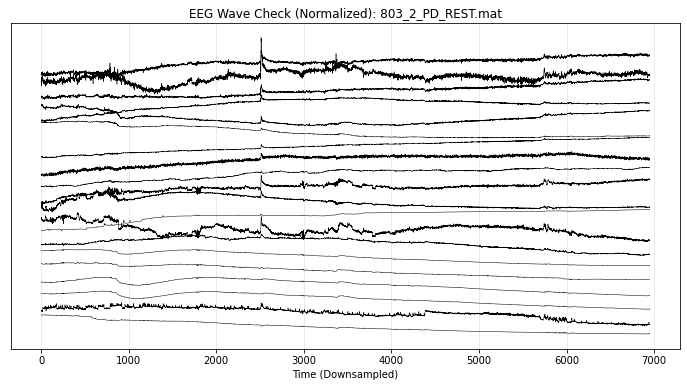

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import mat73
import scipy.io
from scipy.signal import butter, filtfilt, iirnotch, welch
from sklearn.decomposition import FastICA

def extract_eeg_info(eeg_struct):
    """Extract EEG data fields into a dictionary."""
    return {
        'subject': eeg_struct.get('subject', 'Unknown'),
        'group': eeg_struct.get('group', 'Unknown'),
        'condition': eeg_struct.get('condition', 'Unknown'),
        'nbchan': int(eeg_struct.get('nbchan', 0)),
        'trials': int(eeg_struct.get('trials', 0)),
        'pnts': int(eeg_struct.get('pnts', 0)),
        'srate': float(eeg_struct.get('srate', 0)),
        'data': eeg_struct.get('data'),
        'data_shape': eeg_struct['data'].shape if 'data' in eeg_struct else (0,0),
        'times': eeg_struct.get('times')
    }

def analyze_eeg_data(file_path):
    try:
        try:
            data = mat73.loadmat(file_path)
        except:
            data = scipy.io.loadmat(file_path)
            
        if 'EEG' in data:
            eeg_content = data['EEG']
            if hasattr(eeg_content, 'dtype') and eeg_content.shape == (1, 1):
                eeg_content = eeg_content[0, 0]
                eeg_content = {name: eeg_content[name] for name in eeg_content.dtype.names}
            return extract_eeg_info(eeg_content)
    except Exception as e:
        print(f"Failed to load {os.path.basename(file_path)}: {e}")
    return None

def plot_eeg_signal(eeg_info, subject_name, num_channels=20):
    """Plot channels with auto-scaling to prevent flat-line effect."""
    data = eeg_info['data']
    if data is None: return

    if len(data.shape) == 3: data = data[0, :, :]
        
    # Downsample for speed
    step = 30
    plot_data = data[:num_channels, ::step]
    
    plt.figure(figsize=(12, 6))
    
    # Auto-scale: Normalize each channel so waves are visible
    for i in range(min(num_channels, plot_data.shape[0])):
        ch_data = plot_data[i]
        # Normalize: (data - mean) / std dev makes waves visible
        std_val = np.nanstd(ch_data)
        normalized = (ch_data - np.nanmean(ch_data)) / (std_val if std_val > 0 else 1)
        plt.plot(normalized + (i * 2.5), color='black', linewidth=0.5)
        
    plt.title(f"EEG Wave Check (Normalized): {subject_name}")
    plt.xlabel("Time (Downsampled)")
    plt.yticks([])
    plt.grid(True, axis='x', alpha=0.3)
    plt.show()

def main():
    current_dir = os.path.join(os.getcwd(), 'PD_REST')
    mat_files = [f for f in os.listdir(current_dir) if f.endswith('.mat') and not f.endswith('1.mat')]
    
    # Pick 4 random subjects
    selected_files = ['803_2_PD_REST.mat', '818_2_PD_REST.mat']
    
    plot_data = None
    plot_subject = None

    for file in selected_files:
        eeg_info = analyze_eeg_data(os.path.join(current_dir, file))
        
        # FIX: Check for NoneType before accessing
        if eeg_info and eeg_info['data'] is not None and eeg_info['data'].size > 0:
            print(f"Successfully loaded {file} | Shape: {eeg_info['data_shape']}")
            if plot_data is None:
                plot_data, plot_subject = eeg_info, file
        else:
            print(f"Skipping {file}: No valid data found.")

    if plot_data:
        plot_eeg_signal(plot_data, plot_subject)

if __name__ == "__main__":
    main()

In [3]:

def extract_channel_labels(chanlocs):
    labels = []
    for ch in chanlocs[0]:
        try:
            label = ch[0]
            while isinstance(label, np.ndarray):
                if label.size == 0:
                    label = "Unknown"
                    break
                label = label.flat[0]
            labels.append(str(label))
        except Exception:
            labels.append("Unknown")
    return labels

In [4]:
from scipy.signal import welch

def plot_psd_all_channels(self, raw_data, subject):

    data = self.preprocess(raw_data)

    plt.figure(figsize=(10,6))

    for ch in range(min(10, data.shape[0])):

        f, pxx = welch(
            data[ch],
            fs=self.srate,
            nperseg=2048
        )

        plt.semilogy(
            f,
            pxx,
            alpha=0.5
        )

    plt.title(f"PSD (First 10 Channels) - {subject}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.xlim(0, 50)

    plt.grid(True)

    plt.show()

In [5]:
def plot_psd_with_bands(self, raw_data, subject):

    data = self.preprocess(raw_data)

    f, pxx = welch(
        data[0],  # one channel (you can change later)
        fs=self.srate,
        nperseg=2048
    )

    plt.figure(figsize=(10,6))

    plt.semilogy(f, pxx, label="PSD")

    # Highlight EEG bands
    plt.axvspan(0.5, 4, alpha=0.2, label='Delta')
    plt.axvspan(4, 8, alpha=0.2, label='Theta')
    plt.axvspan(8, 13, alpha=0.2, label='Alpha')
    plt.axvspan(13, 30, alpha=0.2, label='Beta')

    plt.title(f"EEG Frequency Bands - {subject}")

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")

    plt.xlim(0, 40)

    plt.legend()

    plt.grid(True)

    plt.show()

In [6]:
def compute_band_power(self, raw_data):

    data = self.preprocess(raw_data)

    bands = {
        'Delta': (0.5, 4),
        'Theta': (4, 8),
        'Alpha': (8, 13),
        'Beta': (13, 30)
    }

    results = {}

    for name, (low, high) in bands.items():

        band_power = []

        for ch in range(data.shape[0]):

            filtered = self.filter_signal(
                data[ch],
                low,
                high
            )

            power = np.mean(filtered**2)

            band_power.append(power)

        results[name] = np.mean(band_power)

    print("\nBand Power Summary:")
    for k, v in results.items():
        print(f"{k}: {v:.4f}")

    return results

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import mne


def plot_ica_topomaps_from_processor(proc, n_components=10):

    if not hasattr(proc, "ica"):
        raise ValueError("ICA not computed")

    raw = proc.raw
    ica = proc.ica

    # ---------------------------------------
    # Standard EEG montage
    # ---------------------------------------
    montage = mne.channels.make_standard_montage("standard_1020")

    # Clean channel names
    raw.rename_channels(lambda x: x.strip())

    # ICA components
    components = ica.get_components()

    # ---------------------------------------
    # Get positions manually
    # ---------------------------------------
    montage_positions = montage.get_positions()["ch_pos"]

    # Keep only channels existing in montage
    valid_channels = [
        ch for ch in raw.ch_names
        if ch in montage_positions
    ]

    if len(valid_channels) == 0:
        raise RuntimeError(
            "No matching EEG channels found in standard_1020 montage."
        )

    # Positions in same order as ICA channels
    pos = np.array([
        montage_positions[ch][:2]
        for ch in valid_channels
    ])

    # Match ICA data to valid channels
    picks = [
        raw.ch_names.index(ch)
        for ch in valid_channels
    ]

    n_components = min(
        n_components,
        components.shape[1]
    )

    fig, axes = plt.subplots(
        1,
        n_components,
        figsize=(3 * n_components, 3)
    )

    axes = np.atleast_1d(axes)

    for ic in range(n_components):

        data = components[picks, ic]

        mne.viz.plot_topomap(
            data,
            pos,
            axes=axes[ic],
            show=False
        )

        axes[ic].set_title(f"IC {ic}")

    plt.tight_layout()
    plt.show()

In [ ]:
path = os.path.join(os.getcwd(), 'PD_REST')
selected_files = ['803_2_PD_REST.mat']
# , '818_2_PD_REST.mat'
bad_components = [0]
for file in selected_files:
    info = load_eeg(os.path.join(path, file))
    labelss = info.get('labels', None)
    print(info.ke)


Processing: 803_2_PD_REST.mat
Labels (67): ['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5'] ...

[1/2] Preparing and filtering data...
  Channels kept : 63
  Data range    : -422566.1 – 3212.4

[2/2] Fitting ICA...
Fitting ICA to data using 63 channels (please be patient, this may take a while)
Selecting by explained variance: 62 components
Computing Extended Infomax ICA


<c:\Users\User\Anaconda3\lib\site-packages\decorator.py:decorator-gen-570>:12: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.


Fitting ICA took 26.0s.
  ICA fitted   : 62 components
  Sources shape: (50000, 62)

Inspect with plot_ica_timeseries() and plot_ica_topomaps_from_processor()
Then call remove_artifacts(bad=[0, 1, 2])


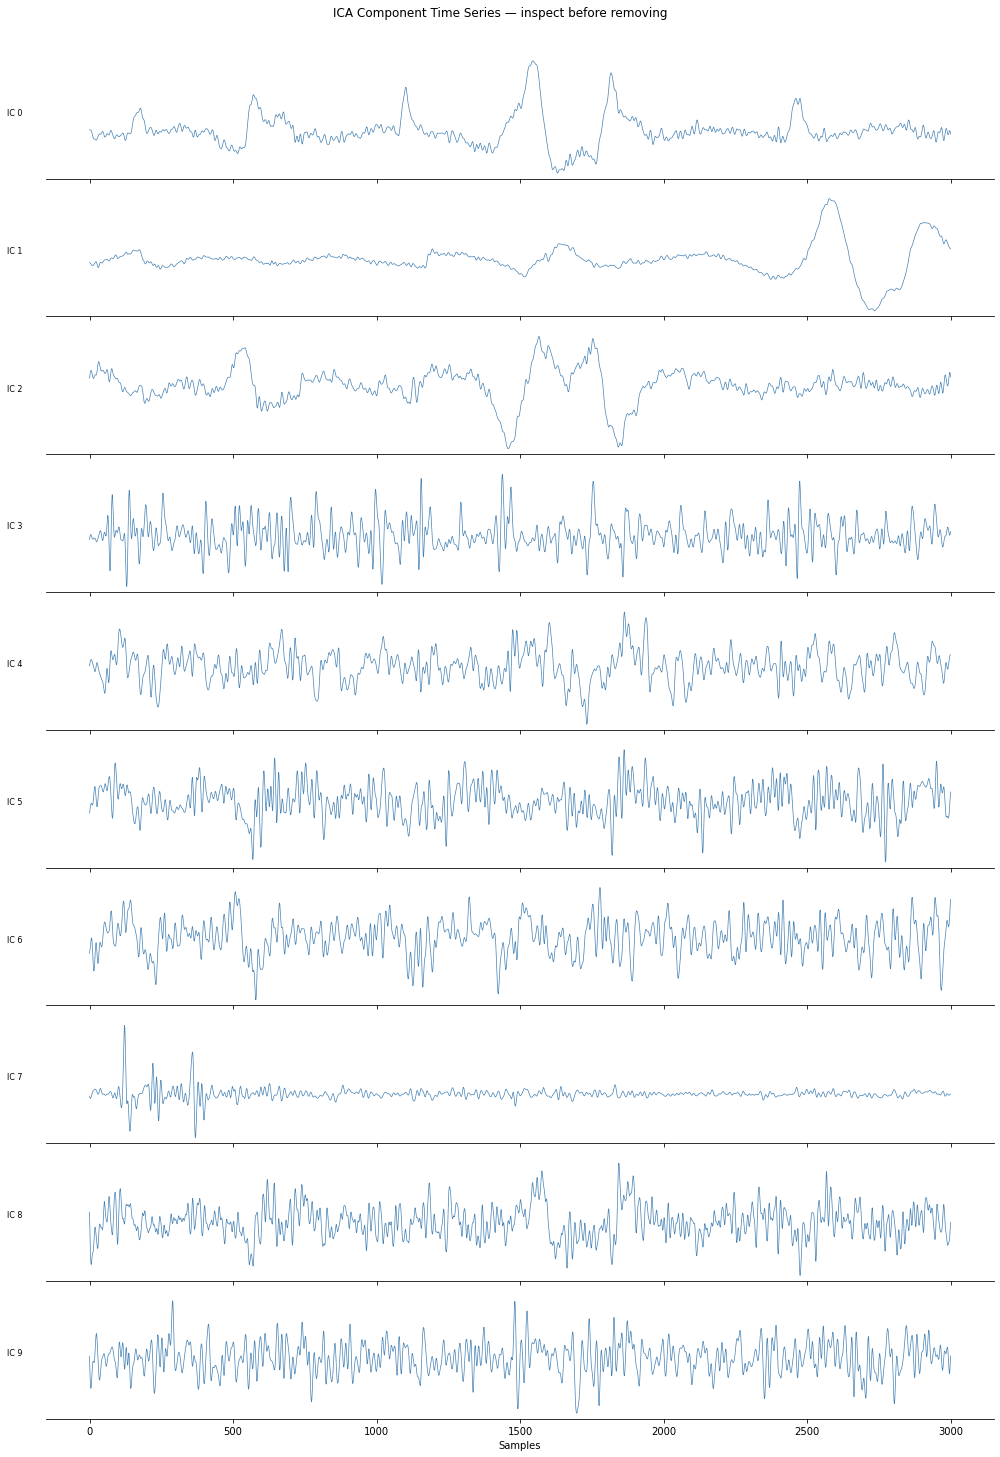

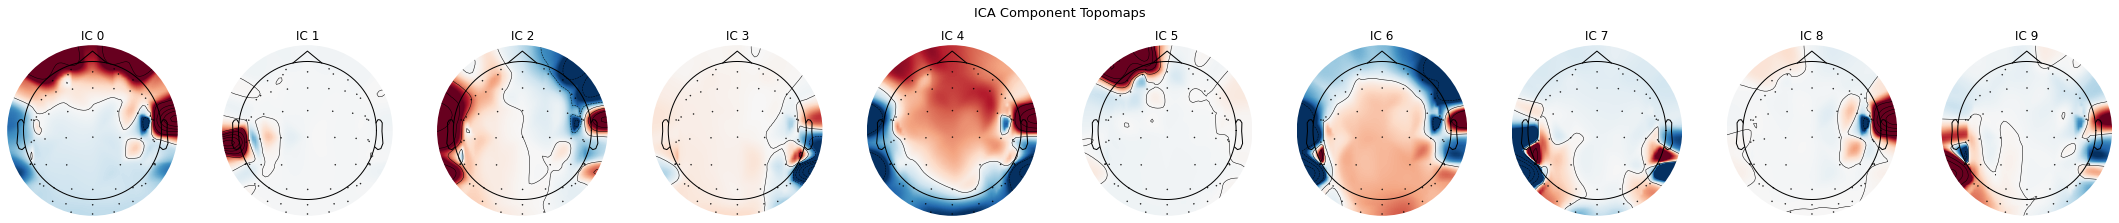


Removing ICA components: [0, 1, 2]
Applying ICA to Raw instance
    Transforming to ICA space (62 components)
    Zeroing out 3 ICA components
    Projecting back using 63 PCA components
Cleaned data shape: (63, 50000)
  Interpolating 1 channels: ['TP10']


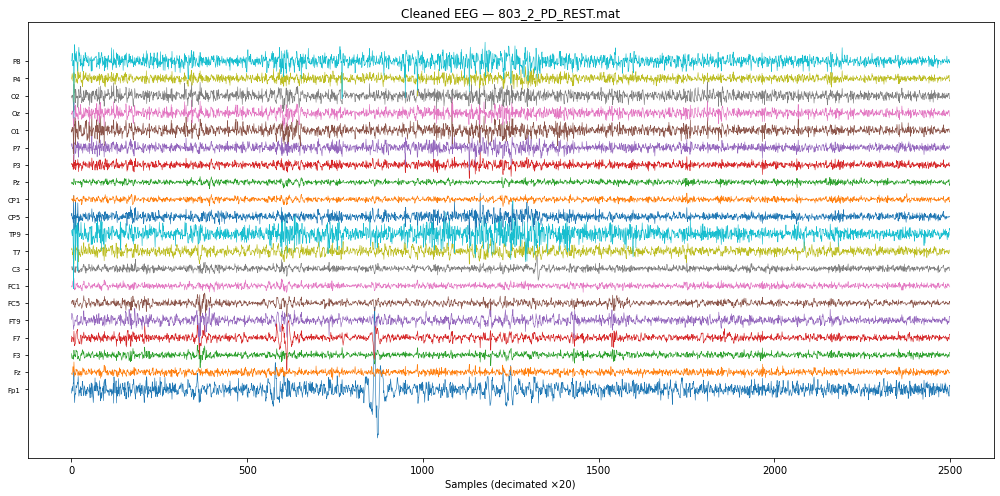

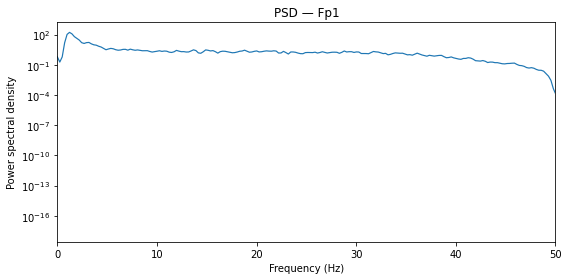

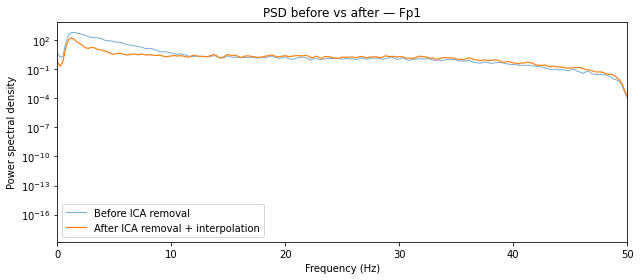

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import os
import mat73
import scipy.io
from mne.preprocessing import ICA
import mne
from scipy.signal import butter, filtfilt, iirnotch, welch


# --------------------------------------------------
# EXTRACT CHANNEL LABELS
# --------------------------------------------------

def extract_channel_labels(chanlocs):
    labels = []
    for ch in chanlocs[0]:
        try:
            label = ch[0]
            while isinstance(label, np.ndarray):
                if label.size == 0:
                    label = "Unknown"
                    break
                label = label.flat[0]
            labels.append(str(label))
        except Exception:
            labels.append("Unknown")
    return labels


# --------------------------------------------------
# TOPOMAP PLOT
# --------------------------------------------------

def plot_ica_topomaps_from_processor(proc, n_components=10):
    if not hasattr(proc, "ica") or not hasattr(proc, "raw"):
        raise ValueError("ICA not fitted yet — call fit_ica() first.")

    ica  = proc.ica
    raw  = proc.raw

    components        = ica.get_components()
    montage           = mne.channels.make_standard_montage("standard_1020")
    montage_positions = montage.get_positions()["ch_pos"]

    valid_channels = [ch for ch in raw.ch_names if ch in montage_positions]
    if not valid_channels:
        raise RuntimeError(
            f"No channels matched standard_1020.\n"
            f"Channels in raw: {raw.ch_names[:10]}"
        )

    pos   = np.array([montage_positions[ch][:2] for ch in valid_channels])
    picks = [raw.ch_names.index(ch) for ch in valid_channels]

    n_plot = min(n_components, components.shape[1])
    fig, axes = plt.subplots(1, n_plot, figsize=(3 * n_plot, 3))
    axes = np.atleast_1d(axes)

    for i in range(n_plot):
        mne.viz.plot_topomap(
            components[picks, i], pos,
            axes=axes[i], show=False, extrapolate='head'
        )
        title = f"IC {i}" + (" ✗" if i in ica.exclude else "")
        axes[i].set_title(title)

    plt.suptitle("ICA Component Topomaps", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# MAIN CLASS
# --------------------------------------------------

class PDBrainProcessor:

    NON_EEG = {'VEOG', 'HEOG', 'X', 'Y', 'Z', 'EMG', 'ECG', 'EOG', 'Status', 'Unknown'}

    def __init__(self, srate):
        self.srate = float(np.squeeze(srate))
        self.bands = {
            'Delta':        (0.5, 4),
            'Theta':        (4,   8),
            'Alpha':        (8,  13),
            'Beta (Motor)': (13, 30),
            'Tremor':       (3,   6),
        }
        self.raw          = None
        self.ica          = None
        self.clean_labels = None
        self.cleaned_data = None

    # --------------------------------------------------
    # INTERNAL HELPERS
    # --------------------------------------------------

    def _prepare_data(self, raw_data, labels):
        data = np.squeeze(raw_data)
        data = data[:, :50000]
        data = self._ensure_channel_first(data)

        n_ch = data.shape[0]
        if len(labels) >= n_ch:
            labels = labels[:n_ch]
        else:
            labels = labels + [f"EEG{i}" for i in range(len(labels), n_ch)]

        keep   = [i for i, l in enumerate(labels) if l not in self.NON_EEG]
        data   = data[keep, :]
        labels = [labels[i] for i in keep]

        print(f"  Channels kept : {len(labels)}")
        print(f"  Data range    : {data.min():.1f} – {data.max():.1f}")
        return data, labels

    def _ensure_channel_first(self, data):
        if data.shape[0] > data.shape[1]:
            data = data.T
        return data
    
    def auto_detect_bad_components(self):
        if self.ica is None or self.raw is None:
            raise RuntimeError("Call fit_ica() first.")

        bad_components = set()

        # Detect eye blinks / EOG
        try:
            eog_indices, _ = self.ica.find_bads_eog(
                self.raw,
                ch_name   = self._pick_frontal_channel(),
                threshold = 3.0,
                verbose   = False
            )
            bad_components.update(eog_indices)
        except Exception:
            pass

        # Detect muscle artifacts
        try:
            muscle_indices, _ = self.ica.find_bads_muscle(
                self.raw,
                threshold = 0.5,
                verbose   = False
            )
            bad_components.update(muscle_indices)
        except Exception:
            pass

        return sorted(bad_components)


    def _pick_frontal_channel(self):
        for ch in ['Fp1', 'Fp2', 'AF3', 'AF4']:
            if ch in self.raw.ch_names:
                return ch
        return self.raw.ch_names[0]

    # --------------------------------------------------
    # FILTERING
    # --------------------------------------------------

    def apply_bandpass(self, data, low=1.0, high=40.0):
        nyq  = 0.5 * self.srate
        b, a = butter(4, [low / nyq, high / nyq], btype='band')
        return filtfilt(b, a, data, axis=-1)

    def apply_notch(self, data, freq=50.0):
        nyq  = 0.5 * self.srate
        b, a = iirnotch(freq / nyq, 35)
        return filtfilt(b, a, data, axis=-1)

    def apply_avg_ref(self, data):
        return data - np.mean(data, axis=0, keepdims=True)

    # --------------------------------------------------
    # STEP 1 — fit ICA
    # --------------------------------------------------

    def fit_ica(self, raw_data, labels):
        print("\n[1/2] Preparing and filtering data...")
        data, labels = self._prepare_data(raw_data, labels)
        self.clean_labels = labels

        data = self.apply_bandpass(data)
        data = self.apply_notch(data)
        data = self.apply_avg_ref(data)
        self._filtered_data = data

        print("\n[2/2] Fitting ICA...")
        info = mne.create_info(ch_names=labels, sfreq=self.srate, ch_types='eeg')
        raw  = mne.io.RawArray(data, info, verbose=False)
        raw.set_montage(
            mne.channels.make_standard_montage("standard_1020"),
            on_missing='ignore'
        )
        self.raw = raw

        ica = ICA(
            n_components=0.999999,
            method='infomax',
            fit_params=dict(extended=True),
            random_state=42,
            max_iter='auto'
        )
        ica.fit(raw, decim=4)
        self.ica = ica

        sources = ica.get_sources(raw).get_data().T
        self._sources = sources

        print(f"  ICA fitted   : {ica.n_components_} components")
        print(f"  Sources shape: {sources.shape}")
        print("\nInspect with plot_ica_timeseries() and plot_ica_topomaps_from_processor()")
        print("Then call remove_artifacts(bad=[0, 1, 2])")

        return sources

    # --------------------------------------------------
    # STEP 2 — remove bad ICA components
    # --------------------------------------------------

    def remove_artifacts(self, bad_components):
        if self.ica is None or self.raw is None:
            raise RuntimeError("Call fit_ica() before remove_artifacts().")

        print(f"\nRemoving ICA components: {bad_components}")

        raw_clean = self.raw.copy()
        self.ica.exclude = bad_components
        self.ica.apply(raw_clean)

        # Update self.raw so interpolation works on the ICA-cleaned signal
        self.raw          = raw_clean
        self.cleaned_data = raw_clean.get_data()

        print(f"Cleaned data shape: {self.cleaned_data.shape}")
        return self.cleaned_data

    # --------------------------------------------------
    # STEP 3 — interpolate bad channels
    # --------------------------------------------------

    def interpolate_bad_channels(self, z_threshold=3.0, max_bad_fraction=0.1):
        """
        max_bad_fraction : float
            Maximum fraction of channels allowed to be interpolated.
            If more are detected, skip interpolation for this subject.
            Default 0.1 = max 10% of channels.
        """
        if self.raw is None:
            raise RuntimeError("Call fit_ica() and remove_artifacts() first.")

        data   = self.raw.get_data()
        labels = self.raw.ch_names
        n_ch   = data.shape[0]

        # ── Criterion 1: high variance ────────────────────────────────
        variances = np.var(data, axis=1)
        mean_var  = np.mean(variances)
        std_var   = np.std(variances)
        bad_var   = [labels[i] for i, v in enumerate(variances)
                    if v > mean_var + z_threshold * std_var]

        # ── Criterion 2: spikes — use stricter threshold ──────────────
        ch_means  = np.mean(data, axis=1, keepdims=True)
        ch_stds   = np.std(data,  axis=1, keepdims=True)
        z_scores  = np.abs((data - ch_means) / (ch_stds + 1e-8))
        bad_spike = [labels[i] for i in range(n_ch)
                    if np.max(z_scores[i]) > 20]   # raised from 10 → 20

        bad_channels = list(set(bad_var + bad_spike))

        # ── Safety check: skip if too many channels flagged ───────────
        max_bad = int(n_ch * max_bad_fraction)
        if len(bad_channels) > max_bad:
            print(f"  ⚠ Too many bad channels ({len(bad_channels)}/{n_ch}) "
                f"— skipping interpolation to protect data integrity.")
            return self.cleaned_data

        if not bad_channels:
            return self.cleaned_data

        print(f"  Interpolating {len(bad_channels)} channels: {bad_channels}")

        raw_interp = self.raw.copy()
        raw_interp.info['bads'] = bad_channels
        raw_interp.interpolate_bads(reset_bads=True, verbose=False)

        self.raw          = raw_interp
        self.cleaned_data = raw_interp.get_data()
        return self.cleaned_data

    # --------------------------------------------------
    # INSPECTION PLOTS  (between fit_ica and remove_artifacts)
    # --------------------------------------------------

    def plot_ica_timeseries(self, num_components=10):
        if not hasattr(self, '_sources'):
            raise RuntimeError("Call fit_ica() first.")
        sources = self._sources
        n = min(num_components, sources.shape[1])
        fig, axes = plt.subplots(n, 1, figsize=(14, 2 * n), sharex=True)
        axes = np.atleast_1d(axes)
        for i in range(n):
            axes[i].plot(sources[:3000, i], lw=0.7, color='steelblue')
            axes[i].set_ylabel(f"IC {i}", fontsize=8, rotation=0, labelpad=28)
            axes[i].set_yticks([])
            for sp in ['top', 'right', 'left']:
                axes[i].spines[sp].set_visible(False)
        axes[-1].set_xlabel("Samples")
        plt.suptitle("ICA Component Time Series — inspect before removing", y=1.01)
        plt.tight_layout()
        plt.show()

    # --------------------------------------------------
    # RESULT PLOTS  (after remove_artifacts / interpolate)
    # --------------------------------------------------

    def plot_eeg_cleaned(self, subject_name, n_channels=20):
        if self.cleaned_data is None:
            raise RuntimeError("Call remove_artifacts() first.")
        step      = 20
        plot_data = self.cleaned_data[:n_channels, ::step]
        spacing   = np.std(self.cleaned_data) * 5

        plt.figure(figsize=(14, 7))
        for i in range(plot_data.shape[0]):
            plt.plot(plot_data[i] + i * spacing, lw=0.6)
        plt.title(f"Cleaned EEG — {subject_name}")
        plt.xlabel("Samples (decimated ×20)")
        plt.yticks(
            [i * spacing for i in range(plot_data.shape[0])],
            self.clean_labels[:n_channels],
            fontsize=7
        )
        plt.tight_layout()
        plt.show()

    def plot_psd(self, channel=0):
        if self.cleaned_data is None:
            raise RuntimeError("Call remove_artifacts() first.")
        sig     = self.cleaned_data[channel]
        f, pxx  = welch(sig, fs=self.srate, nperseg=2048)
        ch_name = self.clean_labels[channel] if self.clean_labels else str(channel)
        plt.figure(figsize=(8, 4))
        plt.semilogy(f, pxx, lw=1.2)
        plt.title(f"PSD — {ch_name}")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power spectral density")
        plt.xlim(0, 50)
        plt.tight_layout()
        plt.show()

    def plot_before_after(self, channel=0):
        if self.cleaned_data is None or not hasattr(self, '_filtered_data'):
            raise RuntimeError("Call fit_ica() and remove_artifacts() first.")
        ch_name = self.clean_labels[channel] if self.clean_labels else str(channel)
        f_before, p_before = welch(self._filtered_data[channel], fs=self.srate, nperseg=2048)
        f_after,  p_after  = welch(self.cleaned_data[channel],   fs=self.srate, nperseg=2048)
        plt.figure(figsize=(9, 4))
        plt.semilogy(f_before, p_before, lw=1.0, label='Before ICA removal', alpha=0.6)
        plt.semilogy(f_after,  p_after,  lw=1.2, label='After ICA removal + interpolation')
        plt.title(f"PSD before vs after — {ch_name}")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power spectral density")
        plt.xlim(0, 50)
        plt.legend()
        plt.tight_layout()
        plt.show()


# --------------------------------------------------
# LOAD EEG
# --------------------------------------------------

def load_eeg(path):
    try:
        data = mat73.loadmat(path)
    except Exception:
        data = scipy.io.loadmat(path)
    eeg = data.get('EEG', {})
    if hasattr(eeg, 'dtype'):
        eeg = {n: eeg[0, 0][n] for n in eeg.dtype.names}
    return eeg


# --------------------------------------------------
# MAIN
# --------------------------------------------------

def main():
    path           = os.path.join(os.getcwd(), 'PD_REST')
    selected_files = ['803_2_PD_REST.mat']
    bad_components = [0, 1, 2]   # IC0=eye blink, IC1=eye movement, IC2=slow drift

    for file in selected_files:
        info = load_eeg(os.path.join(path, file))

        if info.get('data') is None or info.get('srate') is None:
            print(f"Missing data or srate: {file}")
            continue

        print(f"\n{'='*50}\nProcessing: {file}\n{'='*50}")

        labels = extract_channel_labels(info['chanlocs'])
        labels = [l for l in labels if l != 'Unknown']
        print(f"Labels ({len(labels)}): {labels[:6]} ...")

        proc = PDBrainProcessor(info['srate'])

        # STEP 1 — filter + fit ICA once
        proc.fit_ica(info['data'], labels)


        # STEP 2 — inspect (look at these, then decide bad_components)
        proc.plot_ica_timeseries(num_components=10)
        plot_ica_topomaps_from_processor(proc, n_components=10)

        # STEP 3 — remove bad ICA components
        proc.remove_artifacts(bad_components)

        # STEP 4 — auto-detect and interpolate bad channels
        proc.interpolate_bad_channels(z_threshold=3.0)

        # STEP 5 — visualise final result
        proc.plot_eeg_cleaned(subject_name=file, n_channels=20)
        proc.plot_psd(channel=0)
        proc.plot_before_after(channel=0)


if __name__ == "__main__":
    main()

In [59]:
import numpy as np
import os


# --------------------------------------------------
# SAVE CLEANED DATA
# --------------------------------------------------

def save_cleaned_data(proc, subject_id, output_dir='cleaned'):
    """
    Save cleaned EEG data, channel labels, and sampling rate to a .npz file.

    Parameters
    ----------
    proc        : PDBrainProcessor  — must have cleaned_data set
    subject_id  : str               — e.g. '803_2_PD_REST'
    output_dir  : str               — folder to save into
    """
    if proc.cleaned_data is None:
        raise RuntimeError("No cleaned data — run the full pipeline first.")

    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"{subject_id}.npz")

    np.savez(
        save_path,
        data    = proc.cleaned_data,          # (n_channels, n_samples)
        labels  = np.array(proc.clean_labels),
        srate   = np.array(proc.srate),
    )
    print(f"Saved cleaned data → {save_path}")
    print(f"  Shape  : {proc.cleaned_data.shape}")
    print(f"  Srate  : {proc.srate} Hz")
    print(f"  Labels : {proc.clean_labels[:5]} ...")
    return save_path


# --------------------------------------------------
# EPOCH DATA
# --------------------------------------------------

def epoch_data(proc, epoch_sec=2.0, overlap=0.5):
    """
    Cut cleaned EEG into fixed-length overlapping epochs.

    Parameters
    ----------
    proc       : PDBrainProcessor   — must have cleaned_data and srate set
    epoch_sec  : float              — epoch length in seconds (default 2.0)
    overlap    : float              — overlap fraction 0–1 (default 0.5 = 50%)

    Returns
    -------
    epochs : np.ndarray  shape (n_epochs, n_channels, n_times)
    """
    if proc.cleaned_data is None:
        raise RuntimeError("No cleaned data — run the full pipeline first.")

    data       = proc.cleaned_data                        # (n_channels, n_samples)
    srate      = proc.srate
    epoch_len  = int(epoch_sec * srate)                   # samples per epoch
    step       = int(epoch_len * (1 - overlap))           # step size in samples
    n_channels, n_samples = data.shape

    # Slide a window across the recording
    starts = np.arange(0, n_samples - epoch_len + 1, step)
    epochs = np.array([data[:, s:s + epoch_len] for s in starts])

    print(f"\nEpoching complete:")
    print(f"  Epoch length : {epoch_sec}s  ({epoch_len} samples)")
    print(f"  Overlap      : {int(overlap*100)}%  (step = {step} samples)")
    print(f"  Total epochs : {len(epochs)}")
    print(f"  Epoch shape  : {epochs.shape}  (n_epochs, n_channels, n_times)")

    return epochs


# --------------------------------------------------
# EXTRACT BAND POWER FEATURES
# --------------------------------------------------

def extract_band_power(epochs, srate, bands):
    """
    Compute mean band power per epoch per channel using Welch PSD.

    Parameters
    ----------
    epochs : np.ndarray   shape (n_epochs, n_channels, n_times)
    srate  : float        sampling rate in Hz
    bands  : dict         e.g. {'Alpha': (8, 13), 'Beta': (13, 30)}

    Returns
    -------
    features : np.ndarray  shape (n_epochs, n_channels * n_bands)
    feat_names : list      column names e.g. ['Fp1_Delta', 'Fp1_Theta', ...]
    """
    n_epochs, n_channels, n_times = epochs.shape
    band_names = list(bands.keys())
    n_bands    = len(band_names)

    features = np.zeros((n_epochs, n_channels * n_bands))

    for e in range(n_epochs):
        for ch in range(n_channels):
            sig        = epochs[e, ch, :]
            f, pxx     = welch(sig, fs=srate, nperseg=min(256, n_times))

            for b, band_name in enumerate(band_names):
                low, high  = bands[band_name]
                idx        = np.where((f >= low) & (f <= high))[0]
                band_power = np.mean(pxx[idx]) if len(idx) > 0 else 0.0
                col        = ch * n_bands + b
                features[e, col] = band_power

    print(f"\nBand power extraction complete:")
    print(f"  Features shape : {features.shape}  (n_epochs, n_channels × n_bands)")
    print(f"  Bands          : {band_names}")

    return features


def make_feature_names(clean_labels, bands):
    """Generate column names like Fp1_Alpha, Fz_Beta, ..."""
    return [
        f"{ch}_{band}"
        for ch in clean_labels
        for band in bands.keys()
    ]


# --------------------------------------------------
# SAVE EPOCHS + FEATURES
# --------------------------------------------------

def save_epochs_and_features(epochs, features, feat_names,
                              subject_id, label, output_dir='epochs'):
    """
    Save epochs and band power features for one subject.

    Parameters
    ----------
    epochs      : np.ndarray  (n_epochs, n_channels, n_times)
    features    : np.ndarray  (n_epochs, n_features)
    feat_names  : list of str
    subject_id  : str         e.g. '803_2'
    label       : int         1 = PD patient, 0 = healthy control
    output_dir  : str
    """
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"{subject_id}.npz")

    np.savez(
        save_path,
        epochs     = epochs,
        features   = features,
        feat_names = np.array(feat_names),
        label      = np.array(label),
    )
    print(f"Saved epochs + features → {save_path}")
    print(f"  Epochs   : {epochs.shape}")
    print(f"  Features : {features.shape}")
    return save_path


# --------------------------------------------------
# VISUALISE EPOCHS
# --------------------------------------------------

def plot_epoch_band_power(features, feat_names, epoch_idx=0):
    """
    Bar chart of band power for one epoch across all channels and bands.
    Useful sanity check after feature extraction.
    """
    plt.figure(figsize=(14, 4))
    plt.bar(range(len(feat_names)), features[epoch_idx], width=1.0)
    plt.title(f"Band power — epoch {epoch_idx}")
    plt.xlabel("Channel × Band")
    plt.ylabel("Power")

    # Only label every N-th tick to keep it readable
    n      = len(feat_names)
    step   = max(1, n // 20)
    ticks  = list(range(0, n, step))
    plt.xticks(ticks, [feat_names[i] for i in ticks], rotation=45, fontsize=7)

    plt.tight_layout()
    plt.show()

In [68]:
def main():
    path = os.path.join(os.getcwd(), 'PD_REST')

    all_files = [f for f in os.listdir(path) if f.endswith('.mat')]

# Skip duplicates — files ending in a digit after REST (e.g. PD_REST1)
    import re
    all_files = [f for f in all_files
                if not re.search(r'REST\d+\.mat$', f)]

    success = []
    failed  = []

    for i, file in enumerate(all_files, 1):
        subject_id = file.replace('.mat', '')
        print(f"[{i}/{len(all_files)}] {subject_id} ... ", end='', flush=True)

        try:
            info = load_eeg(os.path.join(path, file))

            if info.get('data') is None or info.get('srate') is None:
                raise ValueError("Missing data or srate")

            if 'PD' in file.upper():
                label = 1
            elif 'HC' in file.upper():
                label = 0
            else:
                label = -1

            labels = extract_channel_labels(info['chanlocs'])
            labels = [l for l in labels if l != 'Unknown']

            proc = PDBrainProcessor(info['srate'])

            # ── Preprocessing ──────────────────────────────────────────
            proc.fit_ica(info['data'], labels)

            # Auto-detect bad components per subject
            bad_components = proc.auto_detect_bad_components()
            proc.remove_artifacts(bad_components)
            proc.interpolate_bad_channels(z_threshold=3.0)

            # ── Save cleaned data ──────────────────────────────────────
            save_cleaned_data(proc, subject_id, output_dir='cleaned')

            # ── Epoch + features ───────────────────────────────────────
            epochs     = epoch_data(proc, epoch_sec=2.0, overlap=0.5)
            features   = extract_band_power(epochs, proc.srate, proc.bands)
            feat_names = make_feature_names(proc.clean_labels, proc.bands)

            save_epochs_and_features(
                epochs, features, feat_names,
                subject_id = subject_id,
                label      = label,
                output_dir = 'epochs'
            )

            success.append((subject_id, bad_components, label))
            print(f"✓  removed ICs={bad_components}  label={label}")

        except Exception as e:
            failed.append((subject_id, str(e)))
            print(f"✗  {e}")
            continue

    # ── Summary ────────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"Processed {len(success)}/{len(all_files)} successfully.")

    if failed:
        print(f"\nFailed ({len(failed)}):")
        for sid, reason in failed:
            print(f"  ✗ {sid}: {reason}")

    print(f"\nRemoved components per subject:")
    for sid, ics, lbl in success:
        print(f"  {'PD' if lbl==1 else 'HC'} | {sid}: ICs={ics}")
    print(f"{'='*60}")


if __name__ == "__main__":
    main()

[1/80] 8010_1_PD_REST ... 
[1/2] Preparing and filtering data...
  Channels kept : 63
  Data range    : -417721.5 – 5220.3

[2/2] Fitting ICA...
Fitting ICA to data using 63 channels (please be patient, this may take a while)
Selecting by explained variance: 62 components
Computing Extended Infomax ICA


<c:\Users\User\Anaconda3\lib\site-packages\decorator.py:decorator-gen-570>:12: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.


Fitting ICA took 27.7s.
  ICA fitted   : 62 components
  Sources shape: (50000, 62)

Inspect with plot_ica_timeseries() and plot_ica_topomaps_from_processor()
Then call remove_artifacts(bad=[0, 1, 2])

Removing ICA components: [0, 7, 9, 12, 20, 22, 24, 28, 29, 32, 33, 54]
Applying ICA to Raw instance
    Transforming to ICA space (62 components)
    Zeroing out 12 ICA components
    Projecting back using 63 PCA components
Cleaned data shape: (63, 50000)
  Interpolating 2 channels: ['Fp2', 'AF8']
Saved cleaned data → cleaned\8010_1_PD_REST.npz
  Shape  : (63, 50000)
  Srate  : 500.0 Hz
  Labels : ['Fp1', 'Fz', 'F3', 'F7', 'FT9'] ...

Epoching complete:
  Epoch length : 2.0s  (1000 samples)
  Overlap      : 50%  (step = 500 samples)
  Total epochs : 99
  Epoch shape  : (99, 63, 1000)  (n_epochs, n_channels, n_times)

Band power extraction complete:
  Features shape : (99, 315)  (n_epochs, n_channels × n_bands)
  Bands          : ['Delta', 'Theta', 'Alpha', 'Beta (Motor)', 'Tremor']
Saved

<c:\Users\User\Anaconda3\lib\site-packages\decorator.py:decorator-gen-570>:12: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.


Fitting ICA took 15.9s.
  ICA fitted   : 62 components
  Sources shape: (50000, 62)

Inspect with plot_ica_timeseries() and plot_ica_topomaps_from_processor()
Then call remove_artifacts(bad=[0, 1, 2])

Removing ICA components: [0, 4, 8, 10, 16, 17, 20, 21, 22, 23, 28, 29, 30, 35, 36, 37, 40]
Applying ICA to Raw instance
    Transforming to ICA space (62 components)
    Zeroing out 17 ICA components
    Projecting back using 63 PCA components
Cleaned data shape: (63, 50000)
  Interpolating 2 channels: ['Fp2', 'AF8']
Saved cleaned data → cleaned\801_1_PD_REST.npz
  Shape  : (63, 50000)
  Srate  : 500.0 Hz
  Labels : ['Fp1', 'Fz', 'F3', 'F7', 'FT9'] ...

Epoching complete:
  Epoch length : 2.0s  (1000 samples)
  Overlap      : 50%  (step = 500 samples)
  Total epochs : 99
  Epoch shape  : (99, 63, 1000)  (n_epochs, n_channels, n_times)

Band power extraction complete:
  Features shape : (99, 315)  (n_epochs, n_channels × n_bands)
  Bands          : ['Delta', 'Theta', 'Alpha', 'Beta (Motor

...

Fitting ICA took 15.1s.
  ICA fitted   : 61 components
  Sources shape: (50000, 61)

Inspect with plot_ica_timeseries() and plot_ica_topomaps_from_processor()
Then call remove_artifacts(bad=[0, 1, 2])

Removing ICA components: [0, 2, 10, 13, 16, 19, 32, 42, 50, 52, 57]
Applying ICA to Raw instance
    Transforming to ICA space (61 components)
    Zeroing out 11 ICA components
    Projecting back using 63 PCA components
Cleaned data shape: (63, 50000)
  ⚠ Too many bad channels (7/63) — skipping interpolation to protect data integrity.
Saved cleaned data → cleaned\907_1_PD_REST.npz
  Shape  : (63, 50000)
  Srate  : 500.0 Hz
  Labels : ['Fp1', 'Fz', 'F3', 'F7', 'FT9'] ...

Epoching complete:
  Epoch length : 2.0s  (1000 samples)
  Overlap      : 50%  (step = 500 samples)
  Total epochs : 99
  Epoch shape  : (99, 63, 1000)  (n_epochs, n_channels, n_times)

Band power extraction complete:
  Features shape : (99, 315)  (n_epochs, n_channels × n_bands)
  Bands          : ['Delta', 'Theta', 'A

<c:\Users\User\Anaconda3\lib\site-packages\decorator.py:decorator-gen-570>:12: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.


Fitting ICA took 15.8s.
  ICA fitted   : 62 components
  Sources shape: (50000, 62)

Inspect with plot_ica_timeseries() and plot_ica_topomaps_from_processor()
Then call remove_artifacts(bad=[0, 1, 2])

Removing ICA components: [0, 2, 11, 14]
Applying ICA to Raw instance
    Transforming to ICA space (62 components)
    Zeroing out 4 ICA components
    Projecting back using 63 PCA components
Cleaned data shape: (63, 50000)
  ⚠ Too many bad channels (14/63) — skipping interpolation to protect data integrity.
Saved cleaned data → cleaned\908_1_PD_REST.npz
  Shape  : (63, 50000)
  Srate  : 500.0 Hz
  Labels : ['Fp1', 'Fz', 'F3', 'F7', 'FT9'] ...

Epoching complete:
  Epoch length : 2.0s  (1000 samples)
  Overlap      : 50%  (step = 500 samples)
  Total epochs : 99
  Epoch shape  : (99, 63, 1000)  (n_epochs, n_channels, n_times)

Band power extraction complete:
  Features shape : (99, 315)  (n_epochs, n_channels × n_bands)
  Bands          : ['Delta', 'Theta', 'Alpha', 'Beta (Motor)', 'Trem

<c:\Users\User\Anaconda3\lib\site-packages\decorator.py:decorator-gen-570>:12: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.


Fitting ICA took 17.8s.
  ICA fitted   : 62 components
  Sources shape: (50000, 62)

Inspect with plot_ica_timeseries() and plot_ica_topomaps_from_processor()
Then call remove_artifacts(bad=[0, 1, 2])

Removing ICA components: [0, 5, 7, 9, 38, 47]
Applying ICA to Raw instance
    Transforming to ICA space (62 components)
    Zeroing out 6 ICA components
    Projecting back using 63 PCA components
Cleaned data shape: (63, 50000)
  Interpolating 3 channels: ['P3', 'Fp1', 'AF7']
Saved cleaned data → cleaned\909_1_PD_REST.npz
  Shape  : (63, 50000)
  Srate  : 500.0 Hz
  Labels : ['Fp1', 'Fz', 'F3', 'F7', 'FT9'] ...

Epoching complete:
  Epoch length : 2.0s  (1000 samples)
  Overlap      : 50%  (step = 500 samples)
  Total epochs : 99
  Epoch shape  : (99, 63, 1000)  (n_epochs, n_channels, n_times)

Band power extraction complete:
  Features shape : (99, 315)  (n_epochs, n_channels × n_bands)
  Bands          : ['Delta', 'Theta', 'Alpha', 'Beta (Motor)', 'Tremor']
Saved epochs + features → 

In [2]:
import glob, numpy as np, re, os

epoch_files = glob.glob('epochs/*.npz')

all_features = []
all_labels   = []
all_epochs   = []

for f in epoch_files:
    d         = np.load(f, allow_pickle=True)
    filename  = os.path.basename(f)

    # Re-derive label from filename
    match   = re.search(r'_(\d+)_', filename)
    session = int(match.group(1)) if match else -1
    label   = 0 if session == 1 else 1   # 0=HC, 1=PD

    all_features.append(d['features'])
    all_labels.append(np.full(len(d['features']), label))
    all_epochs.append(d['epochs'])

X      = np.vstack(all_features)
y      = np.concatenate(all_labels)
epochs = np.vstack(all_epochs)

print(f"Total epochs : {X.shape[0]}")
print(f"Features     : {X.shape[1]}")
print(f"PD={np.sum(y==1)}  HC={np.sum(y==0)}")

Total epochs : 15560
Features     : 315
PD=5544  HC=10016


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Total epochs         : 15560
Original features    : 315
PCA components (95%) : 22
Latent shape         : (15560, 22)


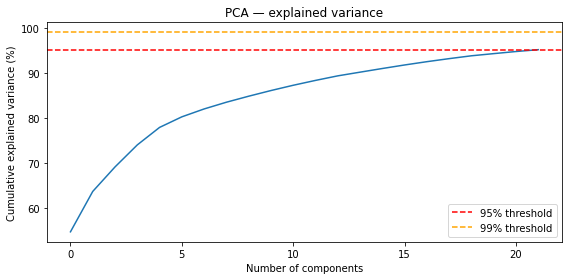

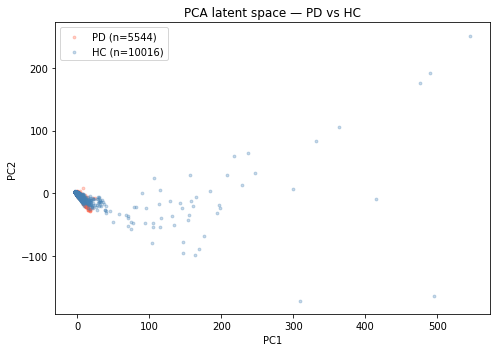


Saved:
  latent_pca.npz  — latent vectors (15560, 22)
  scaler.pkl      — for normalization
  pca.pkl         — for inverse transform after generation


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------------------------------------
# NORMALIZE
# --------------------------------------------------

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------------------
# PCA — find components explaining 95% variance
# --------------------------------------------------

pca   = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Total epochs         : {X.shape[0]}")
print(f"Original features    : {X.shape[1]}")
print(f"PCA components (95%) : {pca.n_components_}")
print(f"Latent shape         : {X_pca.shape}")

# --------------------------------------------------
# EXPLAINED VARIANCE PLOT
# --------------------------------------------------

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100, lw=1.5)
plt.axhline(95, color='r', linestyle='--', label='95% threshold')
plt.axhline(99, color='orange', linestyle='--', label='99% threshold')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance (%)")
plt.title("PCA — explained variance")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2D VISUALIZATION
# --------------------------------------------------

pca_2d = PCA(n_components=2, random_state=42)
X_2d   = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
for label, name, color in [(1, 'PD', 'tomato'), (0, 'HC', 'steelblue')]:
    mask = y == label
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                label=f"{name} (n={mask.sum()})",
                alpha=0.3, s=8, color=color)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA latent space — PD vs HC")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# SAVE
# --------------------------------------------------

np.savez('latent_pca.npz',
         X_latent  = X_pca,
         X_scaled  = X_scaled,
         y         = y,
)

# Save scaler and pca separately so you can inverse transform later
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('pca.pkl', 'wb') as f:
    pickle.dump(pca, f)

print(f"\nSaved:")
print(f"  latent_pca.npz  — latent vectors {X_pca.shape}")
print(f"  scaler.pkl      — for normalization")
print(f"  pca.pkl         — for inverse transform after generation")

## AUTOENCODERS

Loaded  : (15560, 315)  PD=5544  HC=10016
After outlier removal : (13720, 315)
Device      : cpu
Input dim   : 315
Latent dim  : 22
Parameters  : 249,041

Training autoencoder for 200 epochs...
 Epoch |   Train Loss |   Val Loss |         LR
------------------------------------------------
     1 |     0.910916 |   0.932875 |   3.00e-04
    10 |     0.398952 |   0.666371 |   3.00e-04
    20 |     0.320636 |   0.318685 |   3.00e-04
    30 |     0.295149 |   0.334884 |   3.00e-04
    40 |     0.268624 |   0.289321 |   3.00e-04
    50 |     0.252596 |   0.236697 |   3.00e-04
    60 |     0.243807 |   0.240050 |   3.00e-04
    70 |     0.235645 |   0.220912 |   3.00e-04
    80 |     0.230885 |   0.231663 |   1.50e-04
    90 |     0.224440 |   0.249481 |   1.50e-04
   100 |     0.223176 |   0.194415 |   1.50e-04
   110 |     0.218812 |   0.193700 |   1.50e-04
   120 |     0.216477 |   0.266414 |   1.50e-04
   130 |     0.211694 |   0.215036 |   7.50e-05
   140 |     0.211607 |   0.197828 | 

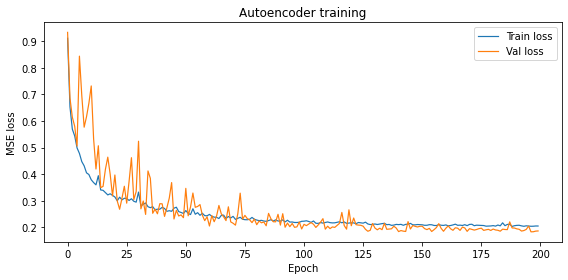

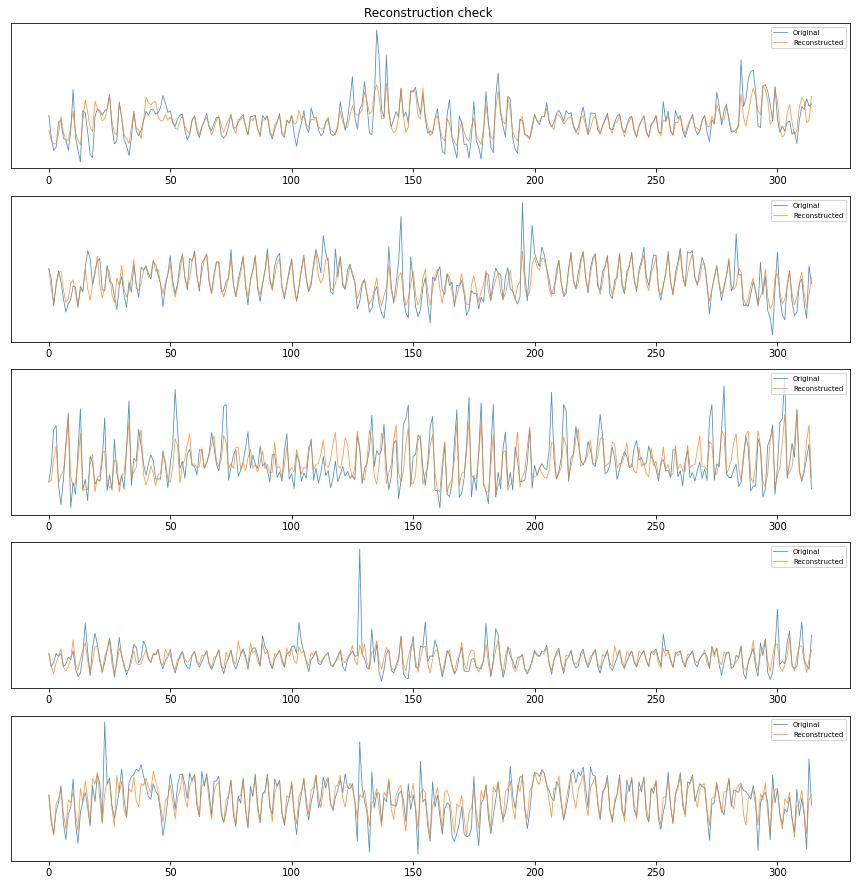


Latent shape : (13720, 22)


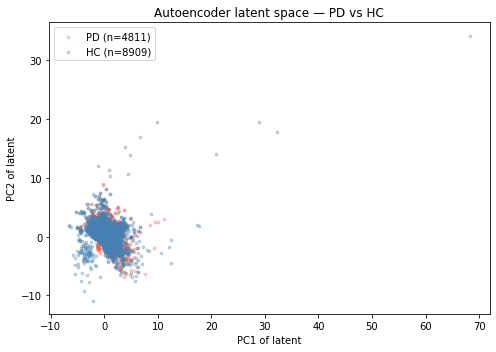


Saved:
  latent_autoencoder.npz   — latent vectors (15560, 22)
  autoencoder_weights.pth  — model weights
  ae_scaler.pkl            — scaler for inverse transform


In [4]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pickle


# --------------------------------------------------
# AUTOENCODER ARCHITECTURE
# --------------------------------------------------

class EEGAutoencoder(nn.Module):

    def __init__(self, input_dim, latent_dim):
        super().__init__()

        # Encoder: input_dim → latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, latent_dim),
        )

        # Decoder: latent_dim → input_dim
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),

            nn.Linear(256, input_dim),
        )

    def forward(self, x):
        z    = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)


# --------------------------------------------------
# TRAINER
# --------------------------------------------------

class AutoencoderTrainer:

    def __init__(self, input_dim, latent_dim=22, lr=1e-3, batch_size=256, epochs=100):
        self.latent_dim  = latent_dim
        self.batch_size  = batch_size
        self.epochs      = epochs
        self.device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        self.model     = EEGAutoencoder(input_dim, latent_dim).to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-5)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, patience=15, factor=0.5, verbose=False
        )
        self.criterion = nn.MSELoss()

        print(f"Device      : {self.device}")
        print(f"Input dim   : {input_dim}")
        print(f"Latent dim  : {latent_dim}")
        print(f"Parameters  : {sum(p.numel() for p in self.model.parameters()):,}")

    def fit(self, X):
        """
        Train the autoencoder on X (n_samples, n_features).
        Returns train/val loss history.
        """
        # Train/val split
        X_train, X_val = train_test_split(X, test_size=0.1, random_state=42)

        train_ds = TensorDataset(torch.FloatTensor(X_train))
        val_ds   = TensorDataset(torch.FloatTensor(X_val))

        train_loader = DataLoader(train_ds, batch_size=self.batch_size, shuffle=True)
        val_loader   = DataLoader(val_ds,   batch_size=self.batch_size)

        train_losses, val_losses = [], []
        best_val_loss = np.inf
        best_weights  = None

        print(f"\nTraining autoencoder for {self.epochs} epochs...")
        print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>10} | {'LR':>10}")
        print("-" * 48)

        for epoch in range(1, self.epochs + 1):
            # ── Train ──────────────────────────────────────────────────
            self.model.train()
            train_loss = 0.0
            for (batch,) in train_loader:
                batch = batch.to(self.device)
                self.optimizer.zero_grad()
                x_hat, _ = self.model(batch)
                loss      = self.criterion(x_hat, batch)
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
                train_loss += loss.item() * len(batch)
            train_loss /= len(train_ds)

            # ── Validate ───────────────────────────────────────────────
            self.model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for (batch,) in val_loader:
                    batch    = batch.to(self.device)
                    x_hat, _ = self.model(batch)
                    val_loss += self.criterion(x_hat, batch).item() * len(batch)
            val_loss /= len(val_ds)

            self.scheduler.step(val_loss)
            train_losses.append(train_loss)
            val_losses.append(val_loss)

            # Save best weights
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_weights  = {k: v.cpu().clone()
                                 for k, v in self.model.state_dict().items()}

            # Print every 10 epochs
            if epoch % 10 == 0 or epoch == 1:
                lr = self.optimizer.param_groups[0]['lr']
                print(f"{epoch:>6} | {train_loss:>12.6f} | {val_loss:>10.6f} | {lr:>10.2e}")

        # Restore best weights
        self.model.load_state_dict(best_weights)
        print(f"\nBest val loss : {best_val_loss:.6f}")
        return train_losses, val_losses

    def encode_all(self, X):
        """Encode full dataset to latent space."""
        self.model.eval()
        with torch.no_grad():
            z = self.model.encode(
                torch.FloatTensor(X).to(self.device)
            ).cpu().numpy()
        return z

    def decode_all(self, Z):
        """Decode latent vectors back to feature space."""
        self.model.eval()
        with torch.no_grad():
            x = self.model.decode(
                torch.FloatTensor(Z).to(self.device)
            ).cpu().numpy()
        return x


# --------------------------------------------------
# PLOTS
# --------------------------------------------------

def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Train loss', lw=1.2)
    plt.plot(val_losses,   label='Val loss',   lw=1.2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title("Autoencoder training")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_latent_space(Z, y, title="Autoencoder latent space — PD vs HC"):
    """2D PCA projection of the latent space for visualization."""
    from sklearn.decomposition import PCA
    pca  = PCA(n_components=2, random_state=42)
    Z_2d = pca.fit_transform(Z)

    plt.figure(figsize=(7, 5))
    for label, name, color in [(1, 'PD', 'tomato'), (0, 'HC', 'steelblue')]:
        mask = y == label
        plt.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                    label=f"{name} (n={mask.sum()})",
                    alpha=0.3, s=8, color=color)
    plt.xlabel("PC1 of latent")
    plt.ylabel("PC2 of latent")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_reconstruction(trainer, X, n_samples=5):
    """Compare original vs reconstructed features for a few samples."""
    idx    = np.random.choice(len(X), n_samples, replace=False)
    X_sub  = X[idx]

    trainer.model.eval()
    with torch.no_grad():
        X_hat, _ = trainer.model(torch.FloatTensor(X_sub).to(trainer.device))
        X_hat    = X_hat.cpu().numpy()

    fig, axes = plt.subplots(n_samples, 1, figsize=(12, 2.5 * n_samples))
    axes = np.atleast_1d(axes)
    for i, ax in enumerate(axes):
        ax.plot(X_sub[i],  lw=0.8, label='Original',       alpha=0.8)
        ax.plot(X_hat[i],  lw=0.8, label='Reconstructed',  alpha=0.8)
        ax.set_yticks([])
        ax.legend(fontsize=7, loc='upper right')
    plt.suptitle("Reconstruction check", fontsize=12)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# MAIN
# --------------------------------------------------
if __name__ == "__main__":

    # ── Reload raw features (before PCA transform) ─────────────────────
    import glob, re, os
    from sklearn.preprocessing import StandardScaler

    epoch_files  = glob.glob('epochs/*.npz')

    all_features = []
    all_labels   = []

    for f in epoch_files:
        d        = np.load(f, allow_pickle=True)
        filename = os.path.basename(f)
        match    = re.search(r'_(\d+)_', filename)
        session  = int(match.group(1)) if match else -1
        label    = 0 if session == 1 else 1

        all_features.append(d['features'])
        all_labels.append(np.full(len(d['features']), label))

    X_raw = np.vstack(all_features)    # (15560, 315) — raw band power
    y     = np.concatenate(all_labels)

    print(f"Loaded  : {X_raw.shape}  PD={np.sum(y==1)}  HC={np.sum(y==0)}")

    # ── Remove outliers ────────────────────────────────────────────────
    from scipy.stats import zscore
    z          = np.abs(zscore(X_raw, axis=0))
    clean_mask = (z < 4).all(axis=1)
    X_raw      = X_raw[clean_mask]
    y          = y[clean_mask]
    print(f"After outlier removal : {X_raw.shape}")

    # ── Normalize ──────────────────────────────────────────────────────
    scaler  = StandardScaler()
    X_clean = scaler.fit_transform(X_raw)

    # ── Train autoencoder ──────────────────────────────────────────────
    trainer = AutoencoderTrainer(
        input_dim  = X_clean.shape[1],   # 315
        latent_dim = 22,
        lr         = 3e-4,
        batch_size = 512,
        epochs     = 200
    )

    train_losses, val_losses = trainer.fit(X_clean)

    plot_loss(train_losses, val_losses)
    plot_reconstruction(trainer, X_clean)

    Z = trainer.encode_all(X_clean)
    print(f"\nLatent shape : {Z.shape}")

    plot_latent_space(Z, y)

    # ── Save ───────────────────────────────────────────────────────────
    np.savez('latent_autoencoder.npz',
             X_latent = Z,
             y        = y)

    torch.save(trainer.model.state_dict(), 'autoencoder_weights.pth')

    import pickle
    with open('ae_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

    print("\nSaved:")
    print("  latent_autoencoder.npz   — latent vectors (15560, 22)")
    print("  autoencoder_weights.pth  — model weights")
    print("  ae_scaler.pkl            — scaler for inverse transform")


Training diffusion model on PCA latent space
PD epochs for training : (2039, 96)


Device     : cpu
Latent dim : 96
T steps    : 1000
Parameters : 923,744

Training DDPM on 2039 PD epochs...
 Epoch |       Loss
----------------------
     1 |   1.058283
    50 |   0.433113
   100 |   0.354821
   150 |   0.329042
   200 |   0.315968
   250 |   0.300079
   300 |   0.290953
   350 |   0.297478
   400 |   0.276306
   450 |   0.285542
   500 |   0.285994

Final loss : 0.285994


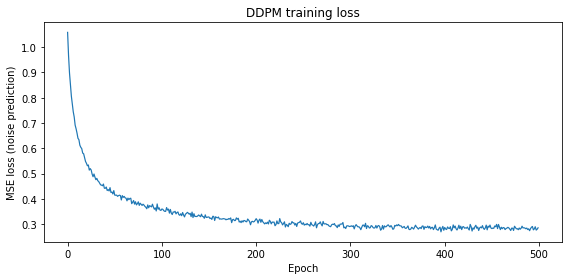

Generated : (2039, 96)


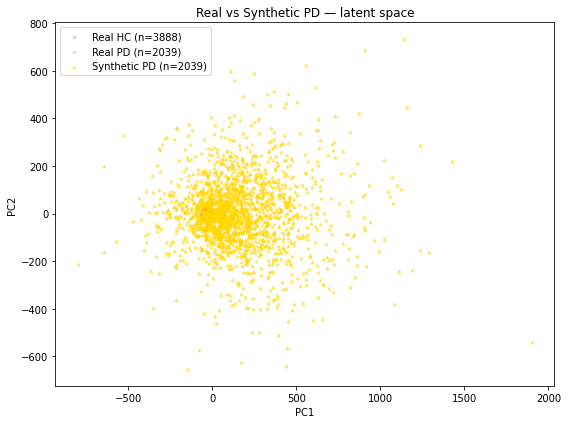


Saved:
  synthetic_pd_pca.npz
  ddpm_pca_weights.pth

Training diffusion model on AE latent space
PD epochs for training : (2039, 22)
Device     : cpu
Latent dim : 22
T steps    : 1000
Parameters : 866,838

Training DDPM on 2039 PD epochs...
 Epoch |       Loss
----------------------
     1 |   0.929903
    50 |   0.251586
   100 |   0.208603
   150 |   0.192752
   200 |   0.179737
   250 |   0.192634
   300 |   0.173495
   350 |   0.174329
   400 |   0.176041
   450 |   0.176400
   500 |   0.169976

Final loss : 0.169976


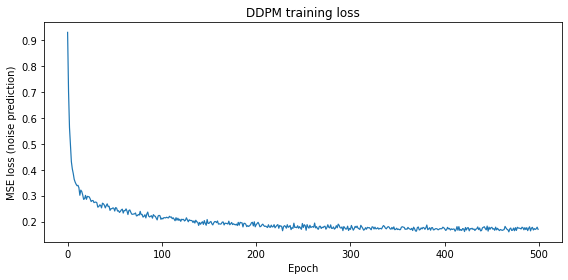

Generated : (2039, 22)


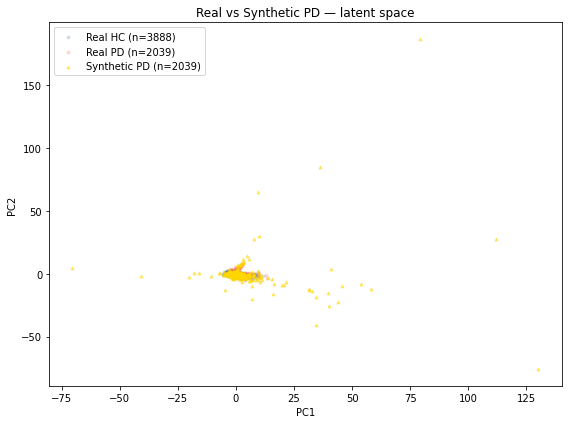


Saved:
  synthetic_pd_ae.npz
  ddpm_ae_weights.pth


In [8]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pickle


# --------------------------------------------------
# NOISE SCHEDULE
# --------------------------------------------------

def make_beta_schedule(T=1000, beta_start=1e-4, beta_end=0.02):
    """
    Linear beta schedule — controls how much noise is added at each step.
    T      : total diffusion steps
    beta_start : noise level at step 0 (very small)
    beta_end   : noise level at step T (large — almost pure noise)
    """
    betas      = torch.linspace(beta_start, beta_end, T)
    alphas     = 1.0 - betas
    alphas_bar = torch.cumprod(alphas, dim=0)   # cumulative product
    return betas, alphas, alphas_bar


# --------------------------------------------------
# FORWARD PROCESS  (add noise)
# --------------------------------------------------

def q_sample(x0, t, alphas_bar, noise=None):
    """
    Add noise to x0 at timestep t.
    This is the closed-form forward process:
    x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * noise
    """
    if noise is None:
        noise = torch.randn_like(x0)

    ab_t  = alphas_bar[t].view(-1, 1)           # (batch, 1)
    x_t   = torch.sqrt(ab_t) * x0 + torch.sqrt(1 - ab_t) * noise
    return x_t, noise


# --------------------------------------------------
# DENOISING NETWORK (the model that learns to remove noise)
# --------------------------------------------------

class DenoisingNetwork(nn.Module):
    """
    Simple MLP that takes (noisy_x, timestep) and predicts the noise.
    Input  : latent vector (22,) + timestep embedding
    Output : predicted noise (22,)
    """

    def __init__(self, latent_dim, T=1000, hidden_dim=256):
        super().__init__()

        # Timestep embedding — tells the model which diffusion step we are at
        self.time_embed = nn.Sequential(
            nn.Embedding(T, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
        )

        # Main denoising network
        self.net = nn.Sequential(
            nn.Linear(latent_dim + hidden_dim, 512),
            nn.LayerNorm(512),
            nn.SiLU(),
            nn.Dropout(0.1),

            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.SiLU(),
            nn.Dropout(0.1),

            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.SiLU(),

            nn.Linear(256, latent_dim),   # predict noise, same dim as input
        )

    def forward(self, x_t, t):
        """
        x_t : noisy latent vector (batch, latent_dim)
        t   : timestep            (batch,)
        """
        t_emb = self.time_embed(t)           # (batch, hidden_dim)
        x_in  = torch.cat([x_t, t_emb], dim=-1)   # concat noise + timestep
        return self.net(x_in)


# --------------------------------------------------
# DDPM TRAINER
# --------------------------------------------------

class DDPMTrainer:

    def __init__(self, latent_dim, T=1000, lr=2e-4, batch_size=256, epochs=500):
        self.T          = T
        self.batch_size = batch_size
        self.epochs     = epochs
        self.device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Noise schedule
        self.betas, self.alphas, self.alphas_bar = make_beta_schedule(T)
        self.betas      = self.betas.to(self.device)
        self.alphas     = self.alphas.to(self.device)
        self.alphas_bar = self.alphas_bar.to(self.device)

        # Model
        self.model     = DenoisingNetwork(latent_dim, T).to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=epochs
        )
        self.criterion = nn.MSELoss()

        print(f"Device     : {self.device}")
        print(f"Latent dim : {latent_dim}")
        print(f"T steps    : {T}")
        print(f"Parameters : {sum(p.numel() for p in self.model.parameters()):,}")

    def fit(self, Z_pd):
        """
        Train on PD latent vectors only.
        Z_pd : np.ndarray (n_pd_epochs, latent_dim)
        """
        dataset = TensorDataset(torch.FloatTensor(Z_pd))
        loader  = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        losses = []
        print(f"\nTraining DDPM on {len(Z_pd)} PD epochs...")
        print(f"{'Epoch':>6} | {'Loss':>10}")
        print("-" * 22)

        for epoch in range(1, self.epochs + 1):
            self.model.train()
            epoch_loss = 0.0

            for (batch,) in loader:
                batch = batch.to(self.device)
                B     = len(batch)

                # Sample random timestep for each sample in batch
                t = torch.randint(0, self.T, (B,), device=self.device)

                # Forward process: add noise
                x_t, noise = q_sample(batch, t, self.alphas_bar)

                # Predict the noise
                noise_pred = self.model(x_t, t)

                # Loss: how well did we predict the noise?
                loss = self.criterion(noise_pred, noise)

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()

                epoch_loss += loss.item() * B

            epoch_loss /= len(Z_pd)
            self.scheduler.step()
            losses.append(epoch_loss)

            if epoch % 50 == 0 or epoch == 1:
                print(f"{epoch:>6} | {epoch_loss:>10.6f}")

        print(f"\nFinal loss : {losses[-1]:.6f}")
        return losses

    @torch.no_grad()
    def generate(self, n_samples):
        """
        Generate n_samples new PD latent vectors using reverse diffusion.
        Starts from pure Gaussian noise and iteratively denoises.
        """
        self.model.eval()
        latent_dim = self.model.net[-1].out_features

        # Start from pure Gaussian noise
        x = torch.randn(n_samples, latent_dim, device=self.device)

        # Reverse process: denoise step by step from T → 0
        for t_val in reversed(range(self.T)):
            t_batch    = torch.full((n_samples,), t_val,
                                    device=self.device, dtype=torch.long)
            noise_pred = self.model(x, t_batch)

            # DDPM reverse step
            alpha      = self.alphas[t_val]
            alpha_bar  = self.alphas_bar[t_val]
            beta       = self.betas[t_val]

            # Mean of reverse distribution
            mean = (1 / torch.sqrt(alpha)) * (
                x - (beta / torch.sqrt(1 - alpha_bar)) * noise_pred
            )

            if t_val > 0:
                # Add noise only if not the last step
                z    = torch.randn_like(x)
                x    = mean + torch.sqrt(beta) * z
            else:
                x    = mean

        return x.cpu().numpy()


# --------------------------------------------------
# PLOTS
# --------------------------------------------------

def plot_diffusion_loss(losses):
    plt.figure(figsize=(8, 4))
    plt.plot(losses, lw=1.2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss (noise prediction)")
    plt.title("DDPM training loss")
    plt.tight_layout()
    plt.show()


def plot_synthetic_vs_real(Z_real, Z_synthetic, y):
    """
    2D PCA plot comparing real PD, real HC, and synthetic PD.
    """
    from sklearn.decomposition import PCA

    # Combine all for PCA fitting
    Z_all  = np.vstack([Z_real, Z_synthetic])
    pca    = PCA(n_components=2, random_state=42)
    pca.fit(Z_all)

    Z_real_2d = pca.transform(Z_real)
    Z_syn_2d  = pca.transform(Z_synthetic)

    plt.figure(figsize=(8, 6))

    # Real HC
    mask_hc = y == 0
    plt.scatter(Z_real_2d[mask_hc, 0], Z_real_2d[mask_hc, 1],
                label=f'Real HC (n={mask_hc.sum()})',
                alpha=0.2, s=8, color='steelblue')

    # Real PD
    mask_pd = y == 1
    plt.scatter(Z_real_2d[mask_pd, 0], Z_real_2d[mask_pd, 1],
                label=f'Real PD (n={mask_pd.sum()})',
                alpha=0.2, s=8, color='tomato')

    # Synthetic PD
    plt.scatter(Z_syn_2d[:, 0], Z_syn_2d[:, 1],
                label=f'Synthetic PD (n={len(Z_synthetic)})',
                alpha=0.5, s=8, color='gold',
                marker='^')

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Real vs Synthetic PD — latent space")
    plt.legend()
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# MAIN
# --------------------------------------------------

if __name__ == "__main__":

    # ── Load latent vectors ────────────────────────────────────────────
    # Run for BOTH latent spaces and compare results

    for latent_file, name in [
        ('latent_pca_clean.npz',    'PCA'),
        ('latent_autoencoder.npz',  'AE'),
    ]:
        print(f"\n{'='*60}")
        print(f"Training diffusion model on {name} latent space")
        print(f"{'='*60}")

        d  = np.load(latent_file)
        Z  = d['X_latent']
        y  = d['y']

        # Keep only PD for training
        Z_pd = Z[y == 1]
        print(f"PD epochs for training : {Z_pd.shape}")

        # Normalize latent space
        scaler = StandardScaler()
        Z_pd_scaled = scaler.fit_transform(Z_pd)

        # Train diffusion model
        trainer = DDPMTrainer(
            latent_dim = Z_pd.shape[1],   # 22
            T          = 1000,
            lr         = 2e-4,
            batch_size = 256,
            epochs     = 500
        )

        losses = trainer.fit(Z_pd_scaled)
        plot_diffusion_loss(losses)

        # Generate synthetic PD samples
        # Generate same number as real PD for balance
        n_generate   = len(Z_pd)
        Z_synthetic  = trainer.generate(n_generate)

        # Inverse scale back to original latent space
        Z_synthetic  = scaler.inverse_transform(Z_synthetic)

        print(f"Generated : {Z_synthetic.shape}")

        # Plot real vs synthetic
        plot_synthetic_vs_real(Z, Z_synthetic, y)

        # Save
        np.savez(f'synthetic_pd_{name.lower()}.npz',
                 Z_synthetic = Z_synthetic,
                 Z_real_pd   = Z_pd,
                 Z_real      = Z,
                 y_real      = y)

        torch.save(trainer.model.state_dict(),
                   f'ddpm_{name.lower()}_weights.pth')

        print(f"\nSaved:")
        print(f"  synthetic_pd_{name.lower()}.npz")
        print(f"  ddpm_{name.lower()}_weights.pth")